<a href="https://colab.research.google.com/github/kdivyasrija/aiml/blob/main/assignment_aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: IMPORT REQUIRED LIBRARIES

# For numerical operations
import numpy as np

# For data manipulation
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.feature_selection import RFE

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# STEP 2: LOAD DATASET
# Loading the financial transaction dataset
df = pd.read_csv("financial_transaction_dataset.csv")

# Printing dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Printing first 2 rows to identify features and target variable
print("\nFirst 2 Rows of Dataset:")
print(df.head(2))

Dataset Shape: (10000, 10)

First 2 Rows of Dataset:
   transaction_id  user_id       amount transaction_type merchant_category  \
0            9608      363  4922.587542              ATM            Travel   
1             456      692    48.018303               QR              Food   

  country  hour  device_risk_score  ip_risk_score  is_fraud  
0      TR    12           0.992347       0.947908         1  
1      US    21           0.168571       0.224057         0  


In [ ]:
# Displaying dataset information
# This shows data types and null values
print("\nDataset Information:")
print(df.info())

# Displaying target distribution
print("\nTarget Distribution:")
print(df['is_fraud'].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None

Target Distribution:
is_fraud
0    9500
1     500
Name: count, dtype: int64


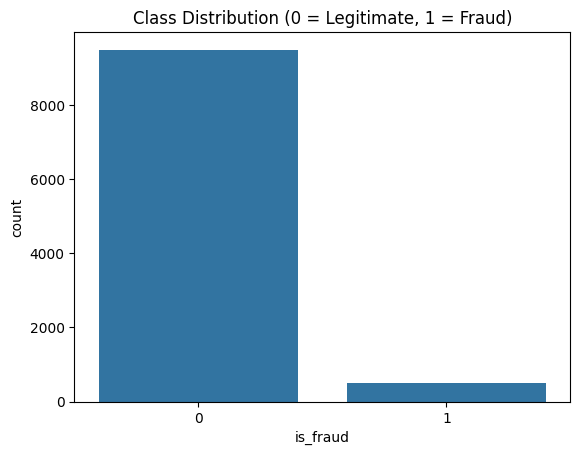

Fraud Percentage: 5.0 %


In [ ]:
# CLASS IMBALANCE VISUALIZATION

# Count plot to visualize number of fraud vs non-fraud transactions
plt.figure()
sns.countplot(x='is_fraud', data=df)
plt.title("Class Distribution (0 = Legitimate, 1 = Fraud)")
plt.show()

# Calculating fraud percentage
fraud_percentage = (df['is_fraud'].value_counts()[1] / len(df)) * 100
print("Fraud Percentage:", fraud_percentage, "%")

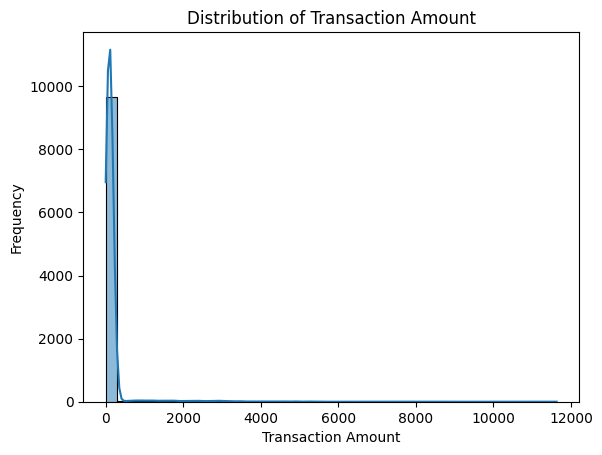

In [ ]:
# Histogram to observe distribution of transaction amounts
plt.figure()
sns.histplot(df['amount'], bins=40, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

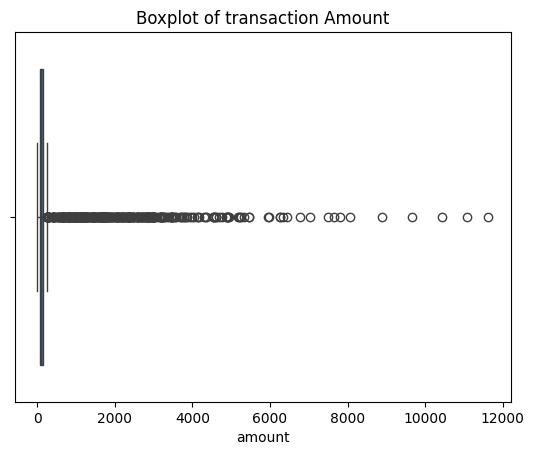

In [ ]:
# Boxplot helps in identifying extreme values (outliers)
plt.figure()
sns.boxplot(x=df['amount'])
plt.title("Boxplot of transaction Amount")
plt.show()

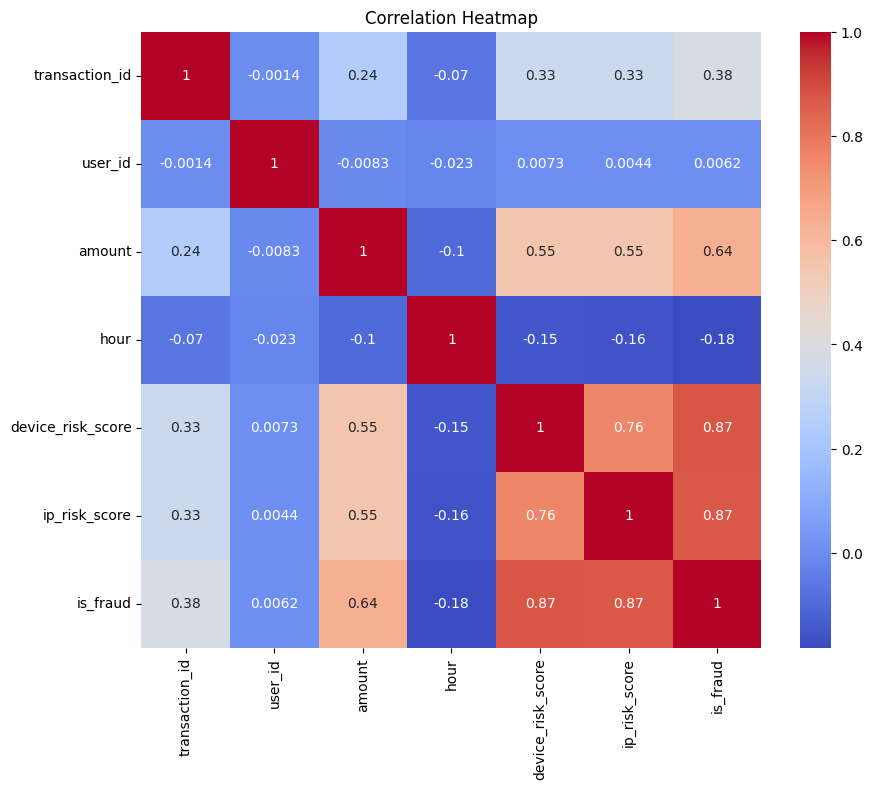

In [ ]:
# CORRELATION ANALYSIS

# Selecting only numerical columns for correlation
numeric_df = df.select_dtypes(include=np.number)

# Generating correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Checking for null values in each column
print("Missing Values in Dataset:\n")
print(df.isnull().sum())

Missing Values in Dataset:

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64


In [ ]:
# Converting categorical variables into numerical format
# Using One-Hot Encoding

df = pd.get_dummies(df, drop_first=True)

print("Categorical Encoding Completed.")

Categorical Encoding Completed.


In [ ]:
# Scaling numerical features to bring them to same range
# Logistic Regression performs better when features are scaled

scaler = StandardScaler()

columns_to_scale = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [ ]:
# Separating features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Temporary Logistic Regression model for feature importance
temp_model = LogisticRegression(max_iter=1000)
temp_model.fit(X, y)

# Extracting coefficients
feature_importance = pd.Series(temp_model.coef_[0], index=X.columns)

# Sorting importance values
feature_importance = feature_importance.sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
device_risk_score           2.058091
ip_risk_score               2.048286
amount                      0.688670
country_NG                  0.111075
hour                       -0.156684
merchant_category_Travel   -0.498983
country_TR                 -0.502606
merchant_category_Food     -0.504734
transaction_type_Online    -0.535060
country_UK                 -0.537691
dtype: float64


In [ ]:
# Splitting dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (8000, 16)
Testing Set Shape: (2000, 16)


In [ ]:
# Creating Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Training model on training data
model.fit(X_train, y_train)

# Predicting on test data
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


In [ ]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[1887    0]
 [   0  113]]


In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1887
           1       1.00      1.00      1.00       113

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



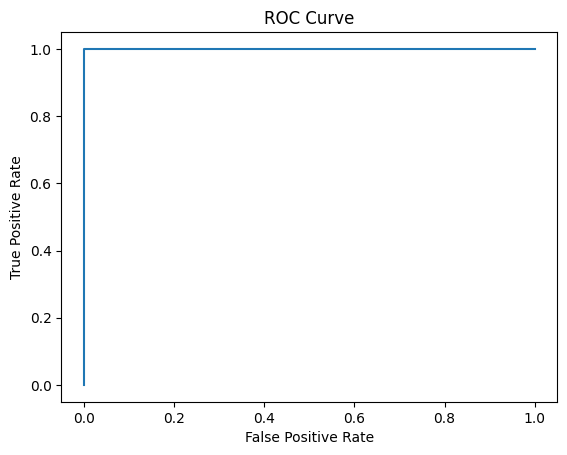

AUC Score: 1.0


In [ ]:
# Predicting probabilities for ROC curve
y_prob = model.predict_proba(X_test)[:,1]

# Calculating ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Printing AUC score
print("AUC Score:", roc_auc_score(y_test, y_prob))

In [ ]:
# Splitting dataset 70% training and 30% testing
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("Accuracy (70-30 Split):", accuracy_score(y_test2, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test2, y_pred2))
print("Classification Report:\n", classification_report(y_test2, y_pred2))

Accuracy (70-30 Split): 1.0
Confusion Matrix:
 [[2838    0]
 [   0  162]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2838
           1       1.00      1.00      1.00       162

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

